# Single CatBoost + Diagnostics + Explainability — LendingClub Interest Rate Prediction

This notebook is the **CatBoost-only** counterpart to `final.ipynb`. Rather than loading
the cached six-base-learner stack, it trains **one CatBoostRegressor** live on the 80%
training fold (early-stopped on the 20% holdout) and uses that single model for everything
downstream.

**Part 1 — Single CatBoost**
Loads + engineers features, builds the full-train target-encoded CatBoost frames, fits one
CatBoost with early stopping on the holdout, reports held-out RMSE / MAE / R2, plots
residual diagnostics, and writes the clipped submission file.

**Part 2 — Diagnostic suite (live)**
1. CatBoost per-round learning curve (train vs val over boosting iterations)
2. sklearn `learning_curve` on CatBoost over training-set size
3. OOF-vs-validation residual distribution overlay (OOF via a live K-fold CatBoost)

**Part 3 — Explainability (live, W2 style)**
Permutation importance, CatBoost native gain, SHAP summary / dependence, PDP / ICE,
SHAP waterfall, LIME, and cross-split SHAP — all on the single CatBoost from Part 1.

**Anti-leakage** (inherited from the pipeline)
- `loan_status` dropped (post-origination outcome)
- Random 80/20 holdout (no date columns in this slice — temporal split impossible)
- K-fold OOF smoothed target encoding for high-cardinality categoricals
- All preprocessing fit on training folds only

> **Prerequisite:** `outputs/sota/tuning_results.json` must exist (cached CatBoost params).
> No `ensemble_artifacts.pkl` is needed — this notebook trains its own model.


---
# Part 1 — Single CatBoost

## 1. Imports + paths

In [1]:
from pathlib import Path
import sys, json, warnings
from time import time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, learning_curve

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'final':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'final'))

# Share one source of truth with the pipeline module.
import final_pipeline as fp

OUT_DIR = fp.OUTPUTS_DIR
print('Project root:', PROJECT_ROOT)
print('Data dir    :', fp.DATA_DIR)
print('Outputs dir :', OUT_DIR)


Project root: c:\Users\liula\Documents\applied ai\project 1
Data dir    : C:\Users\liula\Documents\applied ai\project 1\true data
Outputs dir : C:\Users\liula\Documents\applied ai\project 1\outputs\final


## 2. Load + drop leakage column

`loan_status` is a post-origination outcome and would leak future information into a
rate model, so the pipeline drops it on load. `ID` is held aside for the submission.

In [2]:
train_raw, test_raw = fp.load_raw()
print('train:', train_raw.shape, '   test:', test_raw.shape)
print('target stats:')
print(train_raw['int_rate'].describe().round(3))


train: (100000, 38)    test: (10000, 38)
target stats:
count    100000.000
mean         12.947
std           5.256
min           6.460
25%           8.190
50%          11.710
75%          16.120
max          30.990
Name: int_rate, dtype: float64


## 3. Feature engineering

Stateless transforms only (FICO midpoint + band, term, underwriting ratios,
interactions, log-tails, `zip3`, missingness flags). Anything that needs a fit
(target encoding, imputation) happens inside the K-fold loop / on the train fold only.

In [3]:
train_fe = fp.engineer(train_raw)
test_fe  = fp.engineer(test_raw)

# Top-N emp_title compaction (fit on train only) — must match the pipeline.
top = train_fe['emp_title'].value_counts().head(fp.EMP_TITLE_TOP_N).index.tolist()
train_fe['emp_title'] = train_fe['emp_title'].where(train_fe['emp_title'].isin(top), 'Other').fillna('Missing').astype(str)
test_fe['emp_title']  = test_fe['emp_title'].where(test_fe['emp_title'].isin(top), 'Other').fillna('Missing').astype(str)

test_ids = test_fe['ID'].copy()
test_fe = test_fe.drop(columns=['ID'])

y_full = train_fe['int_rate'].values.astype(np.float64)
X_full = train_fe.drop(columns=['int_rate'])
print('engineered cols:', X_full.shape[1])
print(list(X_full.columns))


engineered cols: 63
['addr_state', 'all_util', 'annual_inc', 'application_type', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'emp_title', 'home_ownership', 'inq_fi', 'inq_last_12m', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'tot_coll_amt', 'tot_cur_bal', 'total_acc', 'total_bal_ex_mort', 'verification_status', 'fico', 'term_months', 'emp_length_num', 'has_mths_since_last_record', 'has_mths_since_recent_inq', 'has_mths_since_rcnt_il', 'has_mths_since_recent_bc', 'loan_to_income', 'installment_proxy', 'bal_to_income', 'util_x_fico', 'dti_x_fico', 'acc_open_ratio', 'dti_band', 'fico_band', 'fico_x_term', 'fico_x_dti_band', 'derog_score', 'inq_intensity', 'revol_util_band', 'all_util_band', 'credit_file_age_yrs', 'term_x_loan_amnt', 'term_x_dti', 

## New interaction terms — rationale

LendingClub does not price `int_rate` as a smooth linear function of any single field; it
prices it off discrete credit tiers and the *joint* interaction of creditworthiness with
loan terms and debt burden. The four engineered terms below were added specifically to
give the trees clean, low-noise splits that mirror how that pricing actually works.

**`fico_band` (finer 8-tier split).** Lender pricing moves in discrete credit-score
brackets, not linearly — the spread between a 695 and a 705 borrower can be far larger
than between a 730 and a 740 because they fall on opposite sides of a pricing cutoff. The
previous 5-bucket split (`[-inf,660,690,720,760,inf]`) was too coarse: it lumped distinct
pricing tiers into one bucket and blurred the exact boundaries where the rate jumps. The
finer 8-tier split (`660/680/700/720/740/760/780`) aligns bucket edges with the
20-point bands where lenders typically re-price, so the model can resolve the tier
boundaries instead of averaging across them.

**`fico_x_term` (FICO × term length).** Rate is set jointly on *creditworthiness* and
*loan tenor*: at any given FICO, a 60-month loan carries a higher rate than a 36-month one
because the lender is exposed to credit risk for longer. FICO and term are the two
strongest raw predictors in this dataset, yet the model had no explicit cross term linking
them. Multiplying them lets a single split capture "high FICO *and* short term" (the
cheapest combination) versus "low FICO *and* long term" (the most expensive), which a tree
would otherwise need many axis-aligned splits to approximate.

**`fico_range_width` (width of the reported FICO band).** Each loan reports a FICO range
(`fico_range_low`, `fico_range_high`); collapsing it to a midpoint throws away the *width*
of that band, which is itself signal. The width reflects how the score was pulled and how
much underwriting uncertainty surrounds the borrower, and it can correlate with how the
rate was ultimately set. Computing `fico_range_high - fico_range_low` before the raw pair
is dropped preserves that information for the model instead of discarding it with the
midpoint collapse.

**`fico_x_dti_band` (FICO × debt-burden tier).** Credit quality and debt-to-income are not
priced independently — the same FICO is priced differently depending on how leveraged the
borrower already is. A strong FICO with low DTI is the prime, cheapest segment, while the
same FICO carrying a high DTI signals stretched affordability and draws a higher rate.
Multiplying `fico` by the discrete `dti_band` tier gives the model a direct handle on this
joint credit-quality × debt-burden effect rather than forcing it to reconstruct the
interaction from the two marginals.

## 4. 80/20 holdout split

Fixed-seed random split (`fp.RANDOM_STATE`, `fp.HOLDOUT_FRAC`) — the same split convention
the stacked pipeline used, so this CatBoost is trained and validated on identical folds.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=fp.HOLDOUT_FRAC, random_state=fp.RANDOM_STATE,
)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
print('X_train:', X_train.shape, '  X_val:', X_val.shape, '  X_test:', test_fe.shape)


X_train: (80000, 63)   X_val: (20000, 63)   X_test: (10000, 63)


## 5. Cached Optuna tuning params

The GBDT hyperparameters tuned by the SOTA Optuna run. We use only the `CatBoost` entry
here.

In [5]:
tuning = json.loads(fp.CACHED_TUNING.read_text())['params']
print('[CatBoost]', tuning['CatBoost'])


[CatBoost] {'learning_rate': 0.03, 'depth': 7, 'l2_leaf_reg': 5.0, 'random_strength': 1.0, 'bagging_temperature': 0.5, 'border_count': 200}


## 6. Build full-train target-encoded CatBoost frames

Smoothed K-fold target encoding is fit on the **train fold only** (`X_train` / `y_train`)
and applied to val and test, then every frame is converted to the CatBoost layout
(native categoricals as strings, everything else float). These full-train frames are
shared by the model fit, Part 2 diagnostics, and the entire Part 3 explainability suite.

In [6]:
from catboost import CatBoostRegressor, Pool

Xtr_te_full, Xval_te_full, Xte_te_full = fp.add_target_encodings(X_train, y_train, X_val, test_fe)
Xtr_cb_full, cat_idx_full = fp.to_catboost_pool(Xtr_te_full)
Xval_cb_full, _ = fp.to_catboost_pool(Xval_te_full)
Xte_cb_full, _ = fp.to_catboost_pool(Xte_te_full)
print('full-train CB frame:', Xtr_cb_full.shape)
print('categorical cols   :', [Xtr_cb_full.columns[i] for i in cat_idx_full])


full-train CB frame: (80000, 67)
categorical cols   : ['zip3', 'emp_title', 'verification_status', 'home_ownership', 'application_type', 'purpose', 'addr_state']


## 7. Train the single CatBoost (early-stopped on the holdout)

One `CatBoostRegressor` on the 80% train fold, with early stopping monitored on the 20%
holdout. The fitted model (`explain_model`) is reused unchanged by every diagnostic and
explainability cell below.

In [7]:
CB_ITERS = 2500

explain_model = CatBoostRegressor(**tuning['CatBoost'], iterations=CB_ITERS,
                                  loss_function='RMSE', eval_metric='RMSE',
                                  random_seed=fp.RANDOM_STATE, verbose=0,
                                  allow_writing_files=False, early_stopping_rounds=100)
t = time()
explain_model.fit(Xtr_cb_full, y_train, cat_features=cat_idx_full,
                  eval_set=(Xval_cb_full, y_val), verbose=False)
val_pred = explain_model.predict(Xval_cb_full)
test_pred = explain_model.predict(Xte_cb_full)
print('CatBoost trained: %d trees  (%.0fs)' % (explain_model.tree_count_, time() - t))


CatBoost trained: 2500 trees  (488s)


## 8. Held-out validation metrics

In [8]:
val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
val_mae  = float(mean_absolute_error(y_val, val_pred))
val_r2   = float(r2_score(y_val, val_pred))
res_df = pd.DataFrame([{'model': 'CatBoost', 'val_RMSE': val_rmse,
                        'val_MAE': val_mae, 'val_R2': val_r2}])
display(res_df.style.format({'val_RMSE': '{:.4f}', 'val_MAE': '{:.4f}', 'val_R2': '{:.4f}'}))
print('val RMSE: %.4f   val MAE: %.4f   val R2: %.4f' % (val_rmse, val_mae, val_r2))


,model,val_RMSE,val_MAE,val_R2
0,CatBoost,3.8698,2.9009,0.4654


val RMSE: 3.8698   val MAE: 2.9009   val R2: 0.4654


## 9. Residual diagnostics

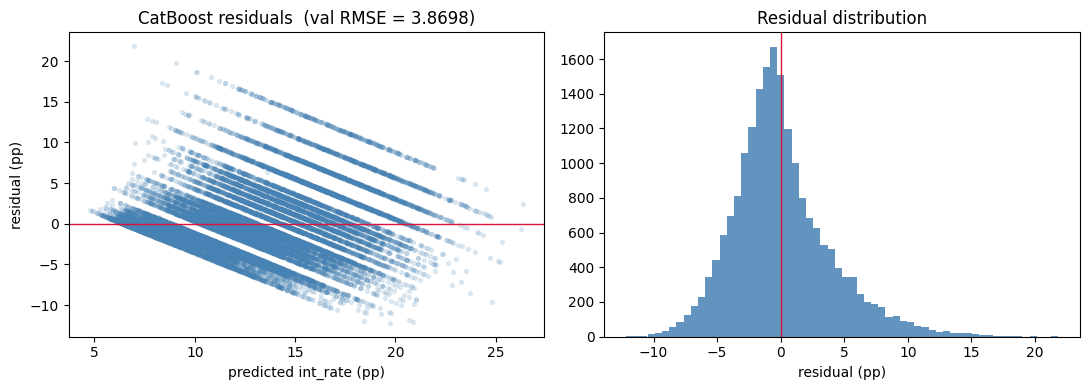

In [9]:
resid = y_val - val_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(val_pred, resid, alpha=0.15, s=8, color='steelblue')
axes[0].axhline(0, color='crimson', lw=1)
axes[0].set_xlabel('predicted int_rate (pp)')
axes[0].set_ylabel('residual (pp)')
axes[0].set_title('CatBoost residuals  (val RMSE = %.4f)' % val_rmse)
axes[1].hist(resid, bins=60, color='steelblue', alpha=0.85)
axes[1].axvline(0, color='crimson', lw=1)
axes[1].set_xlabel('residual (pp)')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_residuals.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Test-set predictions

Predictions are clipped to `[6.0, 31.0]` (observed `int_rate` range in train) and
written with the required `ID, int_rate` schema.

In [10]:
final_test = np.clip(test_pred, 6.0, 31.0)
sub = pd.DataFrame({'ID': test_ids.values, 'int_rate': final_test})
sub_path = OUT_DIR / 'catboost_test_predictions.csv'
sub.to_csv(sub_path, index=False)
print('Saved %d predictions -> %s' % (len(sub), sub_path))
print()
print('int_rate distribution:')
print(sub['int_rate'].describe().round(3))
display(sub.head(10))


Saved 10000 predictions -> C:\Users\liula\Documents\applied ai\project 1\outputs\final\catboost_test_predictions.csv

int_rate distribution:
count    10000.000
mean        11.952
std          3.317
min          6.000
25%          9.376
50%         11.785
75%         14.310
max         23.357
Name: int_rate, dtype: float64


,ID,int_rate
0,1,12.914171
1,2,14.736912
2,3,8.915476
3,4,15.797607
4,5,16.196181
5,6,7.506579
6,7,12.050966
7,8,8.763333
8,9,14.222006
9,10,19.479174


---
# Part 2 — Diagnostic Suite (run live)

Three plots for a single model: whether it is over-, under-, or well-fit, whether more
data would help, and whether the held-out 20% generalises like the cross-validated folds.

## Plot 1 — CatBoost per-round learning curve

Train RMSE and val RMSE against boosting iteration for the model fit in Part 1 (its
captured `evals_result`). The dashed line marks the **best iteration** (lowest val RMSE,
where early stopping rolls the deployed model back to). The badge reports the val-train
gap **at that iteration**.

Reading guide (standard GBDT practice):
* **Large persistent gap, both still falling** → underfit on val. Reduce capacity, raise regularisation, or add data.
* **Small gap at the best-iteration line** → well-fit at the early-stopping point.
* **Train still falling, val rising past the line** → late-stage overfit; the patience tail the model discards.
* **Train and val identical and high** → severe underfit; raise depth or reduce regularisation.

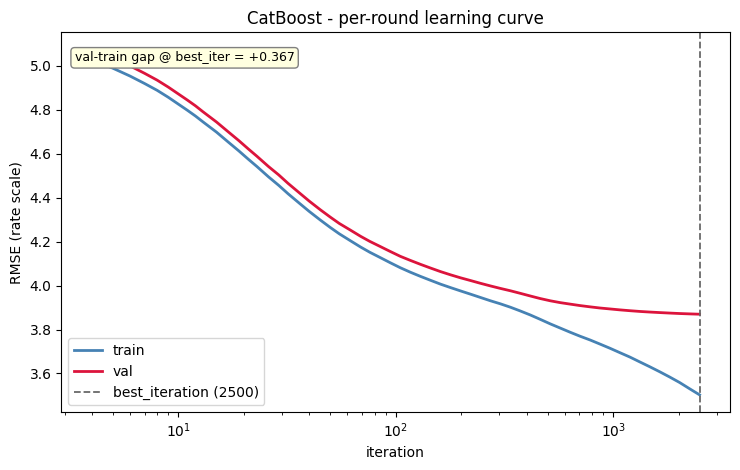

In [11]:
ev = explain_model.get_evals_result()
trc = np.array(ev['learn']['RMSE'])
vac = np.array(ev['validation']['RMSE'])
best_pos = int(np.argmin(vac))


def _sample_idx(n):
    s = np.unique(np.round(np.geomspace(5, n, 60)).astype(int)) - 1
    return s[s < n]


si = _sample_idx(len(vac))
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(si, trc[si], color='steelblue', label='train', linewidth=2)
ax.plot(si, vac[si], color='crimson', label='val', linewidth=2)
ax.axvline(best_pos, color='dimgrey', linestyle='--', linewidth=1.3,
           label='best_iteration (%d)' % (best_pos + 1))
ax.set_xscale('log')
ax.set_xlabel('iteration')
ax.set_ylabel('RMSE (rate scale)')
ax.set_title('CatBoost - per-round learning curve')
ax.legend()
gap_best = float(vac[best_pos] - trc[best_pos])
ax.text(0.02, 0.95, 'val-train gap @ best_iter = %+.3f' % gap_best,
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(facecolor='lightyellow', edgecolor='grey', boxstyle='round'))
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_diag_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## Plot 2 — sklearn `learning_curve` on CatBoost over training-set sizes

For a few training-set fractions we refit a smaller CatBoost and record train + CV RMSE.
Tells us whether more data would still help.

Reading guide:
* **CV RMSE still falling at 100%** → data-limited. Adding rows would reduce RMSE.
* **CV RMSE flat / rising at 100%** → capacity-limited. More data won't help; raise capacity instead.

Computing sklearn learning_curve on CatBoost over training-set size...
  done in 333s


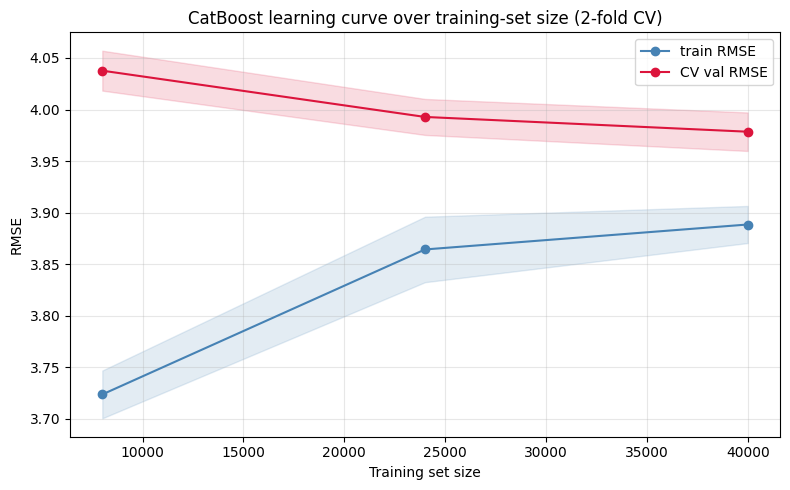


CV val RMSE slope between last two points: -0.000001 per row
  -> CV RMSE flat - capacity-saturated at this depth/iterations.


In [12]:
from sklearn.base import BaseEstimator, RegressorMixin

# Data-size-curve runtime knobs (raise for full-strength curves).
LC_SIZE_ITERS = 300
LC_SIZE_FRACTIONS = 3
LC_SIZE_CV = 2


class CatBoostFitShim(RegressorMixin, BaseEstimator):
    # Explicit constructor params (no **kwargs) so sklearn clone/get_params work:
    # sklearn silently drops VAR_KEYWORD params, and clone asserts each param is
    # stored verbatim, so we keep them unmodified and only transform inside fit().
    def __init__(self, cat_idx=None, columns=None, iterations=300,
                 learning_rate=0.03, depth=7, l2_leaf_reg=5.0,
                 loss_function='RMSE', eval_metric='RMSE'):
        self.cat_idx = cat_idx
        self.columns = columns
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.loss_function = loss_function
        self.eval_metric = eval_metric

    def fit(self, X, y):
        self.model_ = CatBoostRegressor(
            iterations=self.iterations, learning_rate=self.learning_rate,
            depth=self.depth, l2_leaf_reg=self.l2_leaf_reg,
            loss_function=self.loss_function, eval_metric=self.eval_metric,
            random_seed=fp.RANDOM_STATE, verbose=0, allow_writing_files=False)
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=list(self.columns))
        else:
            X = X.copy()
        for i in self.cat_idx:
            c = X.columns[i]
            X[c] = X[c].astype('string').fillna('Missing')
        self.feat_cols_ = X.columns.tolist()
        self.model_.fit(X, y, cat_features=list(self.cat_idx), verbose=False)
        return self

    def predict(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feat_cols_)
        else:
            X = X.copy()
        for i in self.cat_idx:
            c = X.columns[i]
            X[c] = X[c].astype('string').fillna('Missing')
        return self.model_.predict(X)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags


print('Computing sklearn learning_curve on CatBoost over training-set size...')
t = time()
shim_lc = CatBoostFitShim(cat_idx=cat_idx_full, columns=Xtr_cb_full.columns,
                          iterations=LC_SIZE_ITERS,
                          learning_rate=tuning['CatBoost'].get('learning_rate', 0.03),
                          depth=tuning['CatBoost'].get('depth', 7),
                          l2_leaf_reg=tuning['CatBoost'].get('l2_leaf_reg', 5.0),
                          loss_function='RMSE', eval_metric='RMSE')
train_sizes_abs, train_scores, val_scores = learning_curve(
    shim_lc, Xtr_cb_full, y_train,
    train_sizes=np.linspace(0.2, 1.0, LC_SIZE_FRACTIONS),
    cv=LC_SIZE_CV, scoring='neg_root_mean_squared_error', n_jobs=1,
    random_state=fp.RANDOM_STATE,
)
print('  done in %.0fs' % (time() - t))

train_rmse_mean = -train_scores.mean(axis=1); train_rmse_std = train_scores.std(axis=1)
val_rmse_mean = -val_scores.mean(axis=1); val_rmse_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_abs, train_rmse_mean, 'o-', color='steelblue', label='train RMSE')
plt.fill_between(train_sizes_abs, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std, color='steelblue', alpha=0.15)
plt.plot(train_sizes_abs, val_rmse_mean, 'o-', color='crimson', label='CV val RMSE')
plt.fill_between(train_sizes_abs, val_rmse_mean - val_rmse_std, val_rmse_mean + val_rmse_std, color='crimson', alpha=0.15)
plt.xlabel('Training set size'); plt.ylabel('RMSE')
plt.title('CatBoost learning curve over training-set size (%d-fold CV)' % LC_SIZE_CV)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_diag_learning_curve_size.png', dpi=120, bbox_inches='tight')
plt.show()

slope = (val_rmse_mean[-1] - val_rmse_mean[-2]) / (train_sizes_abs[-1] - train_sizes_abs[-2])
print()
print('CV val RMSE slope between last two points: %.6f per row' % slope)
if slope < -1e-5:
    print('  -> CV RMSE still falling - more data would help.')
elif slope > 1e-5:
    print('  -> CV RMSE rising - capacity-limited, more data will not help.')
else:
    print('  -> CV RMSE flat - capacity-saturated at this depth/iterations.')


## Plot 3 — OOF-vs-val residual distribution overlay

The held-out 20% is a single draw; to check that the model generalises *consistently*
we also build honest out-of-fold predictions on the 80% train fold via a live K-fold
CatBoost (target encoding refit inside each fold, so no leakage). If the OOF and val
residual distributions match, generalisation is stable across folds and the held-out
RMSE is a trustworthy test-RMSE estimate. If they diverge (val tails fatter), the single
held-out split is not representative.

In [13]:
# OOF runtime knob (fewer iterations than the deployed model keeps this affordable).
OOF_CB_ITERS = 1500

kf = KFold(n_splits=fp.N_FOLDS, shuffle=True, random_state=fp.RANDOM_STATE)
oof_pred = np.zeros(len(X_train))
t = time()
for fold_id, (tr_i, va_i) in enumerate(kf.split(X_train)):
    Xtr_f, Xva_f = X_train.iloc[tr_i], X_train.iloc[va_i]
    ytr_f, yva_f = y_train[tr_i], y_train[va_i]
    Xtr_f_te, Xva_f_te, _ = fp.add_target_encodings(Xtr_f, ytr_f, Xva_f, test_fe)
    Xtr_f_cb, cidx_f = fp.to_catboost_pool(Xtr_f_te)
    Xva_f_cb, _ = fp.to_catboost_pool(Xva_f_te)
    m = CatBoostRegressor(**tuning['CatBoost'], iterations=OOF_CB_ITERS,
                          loss_function='RMSE', eval_metric='RMSE',
                          random_seed=fp.RANDOM_STATE, verbose=0,
                          allow_writing_files=False, early_stopping_rounds=100)
    m.fit(Xtr_f_cb, ytr_f, cat_features=cidx_f, eval_set=(Xva_f_cb, yva_f), verbose=False)
    oof_pred[va_i] = m.predict(Xva_f_cb)
    print('  fold %d/%d  OOF RMSE=%.4f  (%.0fs)' % (
        fold_id + 1, fp.N_FOLDS,
        np.sqrt(mean_squared_error(yva_f, oof_pred[va_i])), time() - t), flush=True)

oof_rmse = float(np.sqrt(mean_squared_error(y_train, oof_pred)))
print('Overall OOF RMSE: %.4f   (val RMSE: %.4f)' % (oof_rmse, val_rmse))


  fold 1/5  OOF RMSE=3.8522  (315s)
  fold 2/5  OOF RMSE=3.9176  (734s)
  fold 3/5  OOF RMSE=3.8819  (1059s)
  fold 4/5  OOF RMSE=3.8585  (1376s)
  fold 5/5  OOF RMSE=3.8481  (1636s)
Overall OOF RMSE: 3.8718   (val RMSE: 3.8698)


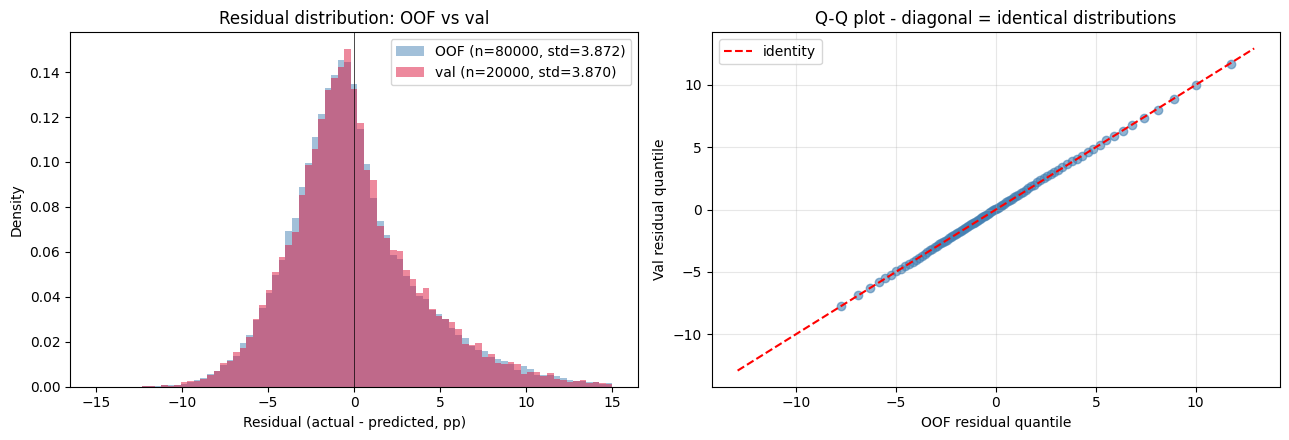


|std(OOF) - std(val)| = 0.0023
  -> Distributions match closely. Cross-fold generalisation looks healthy.


In [14]:
resid_oof = y_train - oof_pred
resid_val = y_val   - val_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-15, 15, 80)
axes[0].hist(resid_oof, bins=bins, alpha=0.5, color='steelblue', density=True,
             label='OOF (n=%d, std=%.3f)' % (len(resid_oof), resid_oof.std()))
axes[0].hist(resid_val, bins=bins, alpha=0.5, color='crimson', density=True,
             label='val (n=%d, std=%.3f)' % (len(resid_val), resid_val.std()))
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Residual (actual - predicted, pp)')
axes[0].set_ylabel('Density')
axes[0].set_title('Residual distribution: OOF vs val')
axes[0].legend()

oof_q = np.quantile(resid_oof, np.linspace(0.01, 0.99, 100))
val_q = np.quantile(resid_val, np.linspace(0.01, 0.99, 100))
axes[1].scatter(oof_q, val_q, alpha=0.6, color='steelblue')
lim = max(abs(oof_q).max(), abs(val_q).max()) * 1.1
axes[1].plot([-lim, lim], [-lim, lim], 'r--', label='identity')
axes[1].set_xlabel('OOF residual quantile')
axes[1].set_ylabel('Val residual quantile')
axes[1].set_title('Q-Q plot - diagonal = identical distributions')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_diag_resid_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

ks_diff = abs(np.std(resid_oof) - np.std(resid_val))
print()
print('|std(OOF) - std(val)| = %.4f' % ks_diff)
if ks_diff < 0.1:
    print('  -> Distributions match closely. Cross-fold generalisation looks healthy.')
elif ks_diff < 0.3:
    print('  -> Mild divergence. Worth checking on a second seed.')
else:
    print('  -> Significant divergence - OOF and val tell different stories. Investigate.')


---
# Part 3 — Explainability (run live, W2 style)

Global (permutation, gain, SHAP) → local (PDP, ICE, waterfall, LIME) → cross-split SHAP.
All explanations use the single CatBoost (`explain_model`) trained in Part 1 on the full
80% training fold and the full-train TE frames built in Part 1.

In [15]:
# Explainability config (raise for full-strength explanations).
PERM_N_REPEATS = 3
SHAP_SAMPLE_SIZE = 800
SHAP_SPLIT_SAMPLE = 500

explain_val_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
print('Explainability CB val_RMSE: %.4f  (trees: %d)' % (explain_val_rmse, explain_model.tree_count_))


Explainability CB val_RMSE: 3.8698  (trees: 2500)


## 11. Permutation importance (validation set)

Each feature is shuffled `PERM_N_REPEATS` times and the mean increase in validation RMSE
is recorded; larger increases indicate more influential features.

Computing permutation importance (n_repeats=3)...
  done in 17s


,feature,perm_mean,perm_std
0,fico,0.298480,0.009570
1,fico_band,0.242788,0.005204
2,term_x_dti,0.150182,0.002073
3,loan_amnt,0.146853,0.001226
4,purpose,0.110315,0.003093
5,mths_since_rcnt_il,0.098890,0.000990
6,fico_x_term,0.090239,0.005678
7,all_util,0.064271,0.001298
8,term_months,0.059077,0.002447
9,application_type,0.058949,0.001311


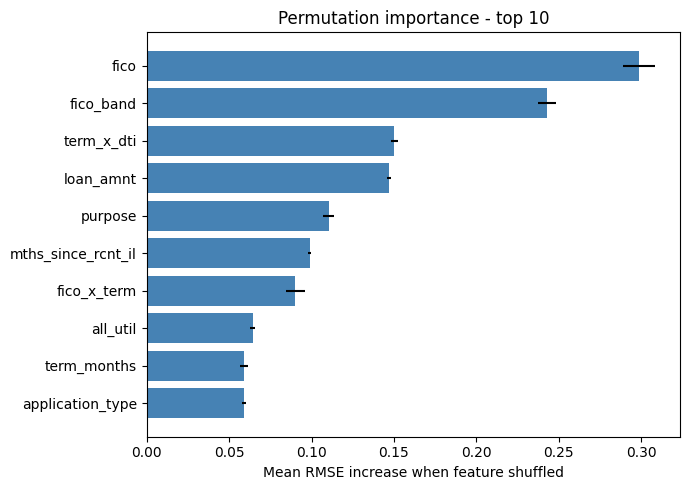

In [16]:
print('Computing permutation importance (n_repeats=%d)...' % PERM_N_REPEATS)
t = time()
rng = np.random.default_rng(fp.RANDOM_STATE)
baseline_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
perm_records = []
for col in Xval_cb_full.columns:
    drops = []
    for r in range(PERM_N_REPEATS):
        Xp = Xval_cb_full.copy()
        Xp[col] = Xp[col].sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000))).values
        rmse_perm = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xp))))
        drops.append(rmse_perm - baseline_rmse)
    perm_records.append({'feature': col, 'perm_mean': float(np.mean(drops)), 'perm_std': float(np.std(drops))})
perm_df = pd.DataFrame(perm_records).sort_values('perm_mean', ascending=False).reset_index(drop=True)
print('  done in %.0fs' % (time() - t))
display(perm_df.head(15))

plt.figure(figsize=(7, 5))
top10 = perm_df.head(10)
plt.barh(top10['feature'][::-1], top10['perm_mean'][::-1], xerr=top10['perm_std'][::-1], color='steelblue')
plt.xlabel('Mean RMSE increase when feature shuffled')
plt.title('Permutation importance - top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_perm_top10.png', dpi=120, bbox_inches='tight')
plt.show()
perm_df.to_csv(OUT_DIR / 'catboost_perm_importance.csv', index=False)


## 12. CatBoost native gain importance

,feature,gain,gain_share
0,fico,10.568493,0.105685
1,fico_band,10.051592,0.100516
2,term_x_dti,5.874811,0.058748
3,loan_amnt,4.604934,0.046049
4,purpose,4.065898,0.040659
5,mths_since_rcnt_il,3.947788,0.039478
6,all_util,3.807588,0.038076
7,fico_x_term,3.763482,0.037635
8,term_months,2.623015,0.026230
9,revol_bal,2.211840,0.022118


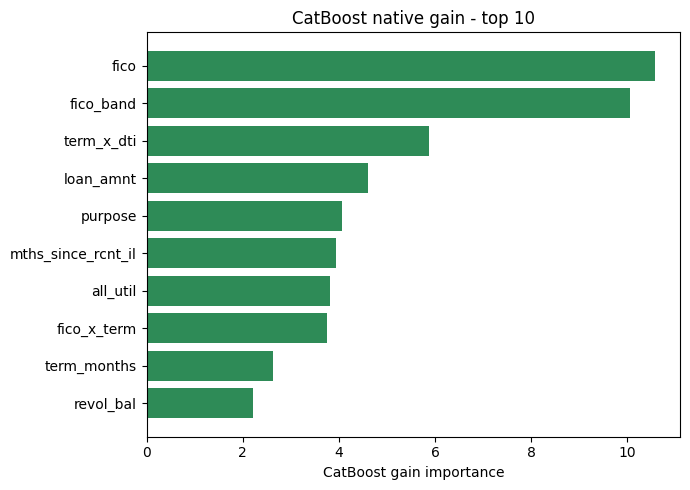

In [17]:
native_imp = pd.DataFrame({
    'feature': Xtr_cb_full.columns,
    'gain': explain_model.get_feature_importance(),
}).sort_values('gain', ascending=False).reset_index(drop=True)
native_imp['gain_share'] = native_imp['gain'] / native_imp['gain'].sum()
display(native_imp.head(15))

plt.figure(figsize=(7, 5))
top10 = native_imp.head(10)
plt.barh(top10['feature'][::-1], top10['gain'][::-1], color='seagreen')
plt.xlabel('CatBoost gain importance')
plt.title('CatBoost native gain - top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_cb_gain_top10.png', dpi=120, bbox_inches='tight')
plt.show()
native_imp.to_csv(OUT_DIR / 'catboost_cb_gain.csv', index=False)


## 13. SHAP — summary and dependence on top features

Computing native CatBoost SHAP on val set...
SHAP shape: (800, 67)  expected: 12.930  (3s)


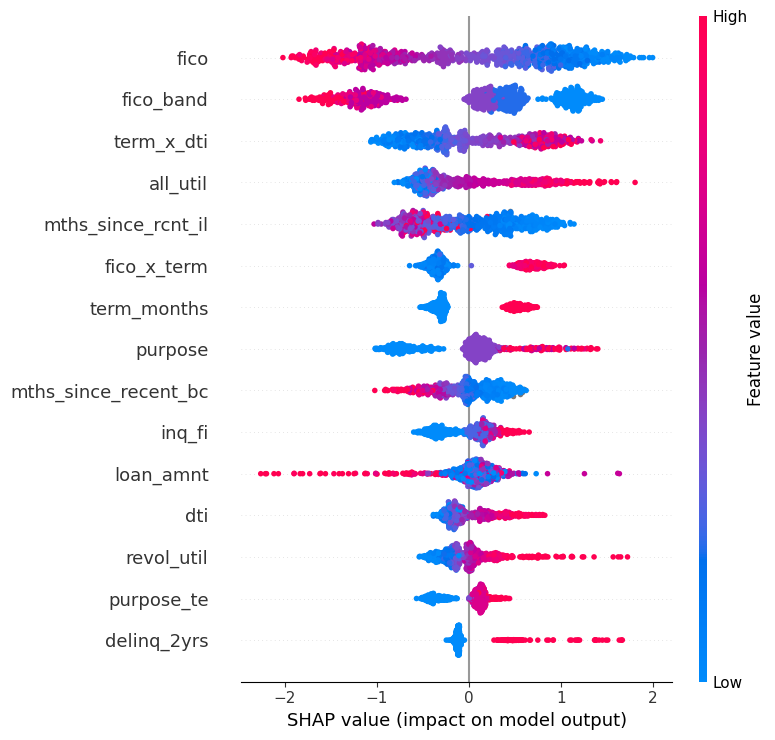

In [18]:
import shap


def cb_to_numeric(df_cb):
    out = df_cb.copy()
    for i in cat_idx_full:
        col = out.columns[i]
        codes, _ = pd.factorize(out[col].astype('string').fillna('Missing'))
        out[col] = codes.astype('int64')
    return out


shap_sample_size = min(SHAP_SAMPLE_SIZE, len(Xval_cb_full))
shap_idx = np.random.default_rng(fp.RANDOM_STATE).choice(len(Xval_cb_full), size=shap_sample_size, replace=False)
Xval_shap_sample = Xval_cb_full.iloc[shap_idx].reset_index(drop=True)

print('Computing native CatBoost SHAP on val set...')
t = time()
pool_val = Pool(Xval_shap_sample, cat_features=cat_idx_full)
shap_with_expected = explain_model.get_feature_importance(pool_val, type='ShapValues')
expected_value = float(shap_with_expected[0, -1])
shap_values_val = shap_with_expected[:, :-1]
print('SHAP shape: %s  expected: %.3f  (%.0fs)' % (str(shap_values_val.shape), expected_value, time() - t))

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_val, cb_to_numeric(Xval_shap_sample),
                  feature_names=list(Xval_shap_sample.columns), max_display=15, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()


Top 5 by mean |SHAP|: ['fico', 'fico_band', 'term_x_dti', 'all_util', 'mths_since_rcnt_il']


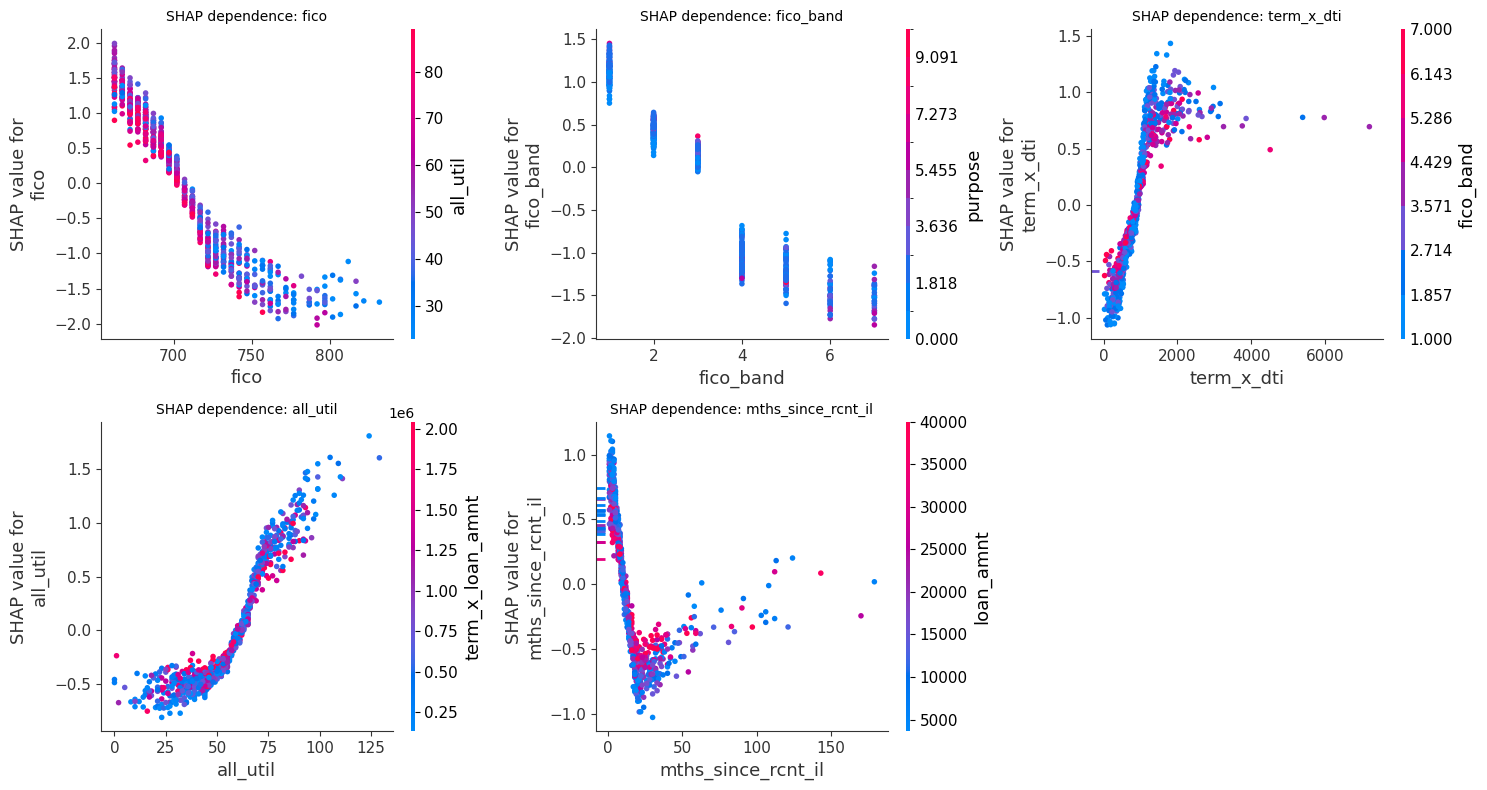

In [19]:
mean_abs_shap = np.abs(shap_values_val).mean(axis=0)
shap_ranking = pd.Series(mean_abs_shap, index=Xval_shap_sample.columns).sort_values(ascending=False)
top5_shap = shap_ranking.head(5).index.tolist()
print('Top 5 by mean |SHAP|:', top5_shap)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
Xval_shap_numeric_sample = cb_to_numeric(Xval_shap_sample)
for i, feat in enumerate(top5_shap):
    shap.dependence_plot(feat, shap_values_val, Xval_shap_numeric_sample,
                         feature_names=list(Xval_shap_sample.columns),
                         ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title('SHAP dependence: ' + feat, fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_shap_dependence_top5.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Partial dependence and ICE — top numeric features

PDP features: ['fico', 'fico_band', 'term_x_dti']


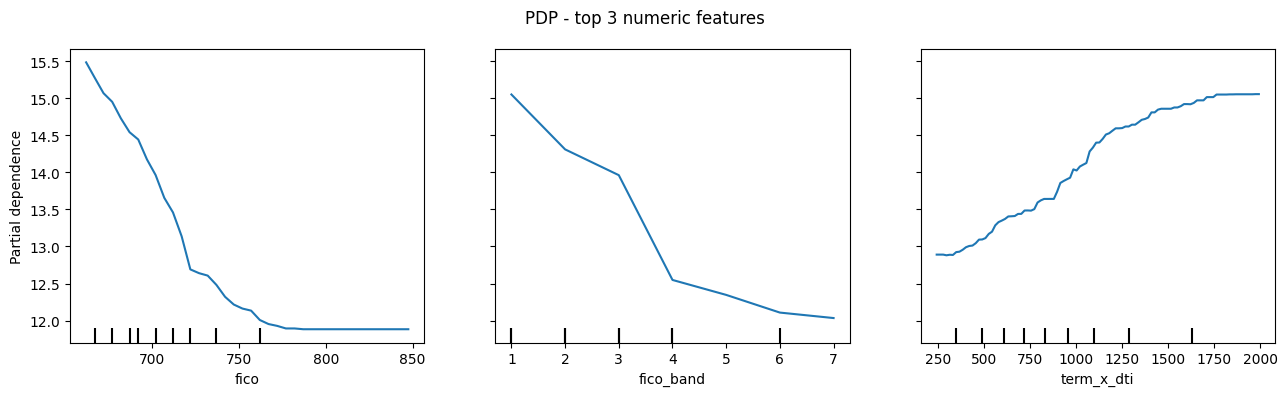

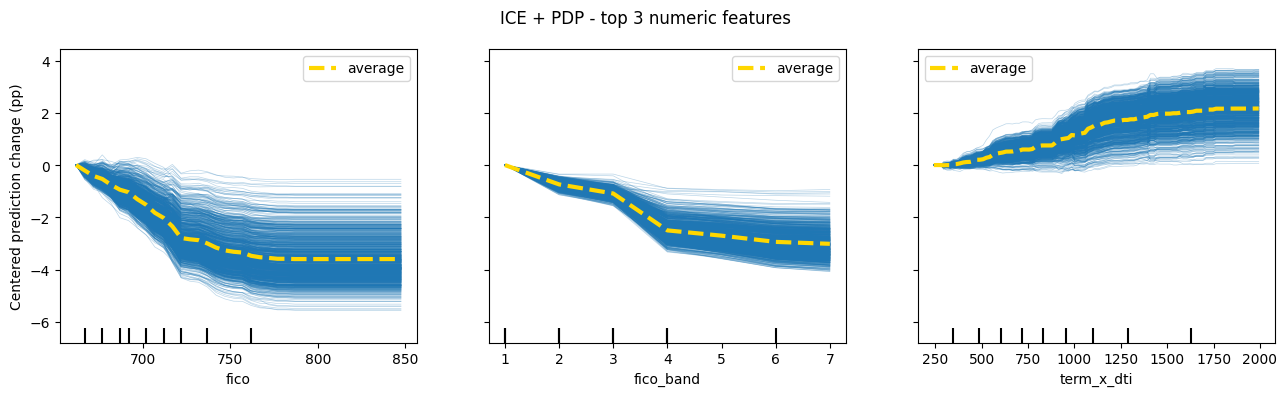

In [20]:
from sklearn.inspection import PartialDependenceDisplay


class CatBoostShim(RegressorMixin, BaseEstimator):
    def __init__(self, model, columns, cat_idx):
        self.model = model
        self.columns = list(columns)
        self.cat_idx = list(cat_idx)
        self.n_features_in_ = len(self.columns)
        self.feature_names_in_ = np.array(self.columns, dtype=object)
        self.is_fitted_ = True

    def __sklearn_is_fitted__(self):
        return True

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        df = pd.DataFrame(X, columns=self.columns)
        for i in self.cat_idx:
            c = self.columns[i]
            df[c] = df[c].astype('string').fillna('Missing')
        for j, c in enumerate(self.columns):
            if j not in self.cat_idx:
                df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
        return self.model.predict(df)


shim_pdp = CatBoostShim(explain_model, Xval_cb_full.columns, cat_idx_full)
Xtr_pdp_numeric = cb_to_numeric(Xtr_cb_full).values
numeric_cols_for_pdp = [c for j, c in enumerate(Xtr_cb_full.columns) if j not in cat_idx_full]
top3_perm_numeric = [f for f in perm_df['feature'] if f in numeric_cols_for_pdp][:3]
print('PDP features:', top3_perm_numeric)

fig, ax = plt.subplots(figsize=(13, 4))
PartialDependenceDisplay.from_estimator(
    shim_pdp, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns), ax=ax, kind='average')
plt.suptitle('PDP - top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_pdp_top3.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
display_ice = PartialDependenceDisplay.from_estimator(
    shim_pdp, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns), kind='both', centered=True, ax=ax,
    pd_line_kw={'color': 'gold', 'linewidth': 3})
display_ice.axes_[0, 0].set_ylabel('Centered prediction change (pp)')
plt.suptitle('ICE + PDP - top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_ice_top3.png', dpi=120, bbox_inches='tight')
plt.show()


## 15. Representative rows — SHAP waterfall and LIME

Low / median / high predicted-rate rows from the CatBoost, explained two ways.

Representative rows:
  low rate (5th pct)     idx=6529  predicted=7.39%  actual=7.02%
  median rate            idx=16259  predicted=12.84%  actual=7.02%
  high rate (95th pct)   idx=9003  predicted=18.97%  actual=20.55%


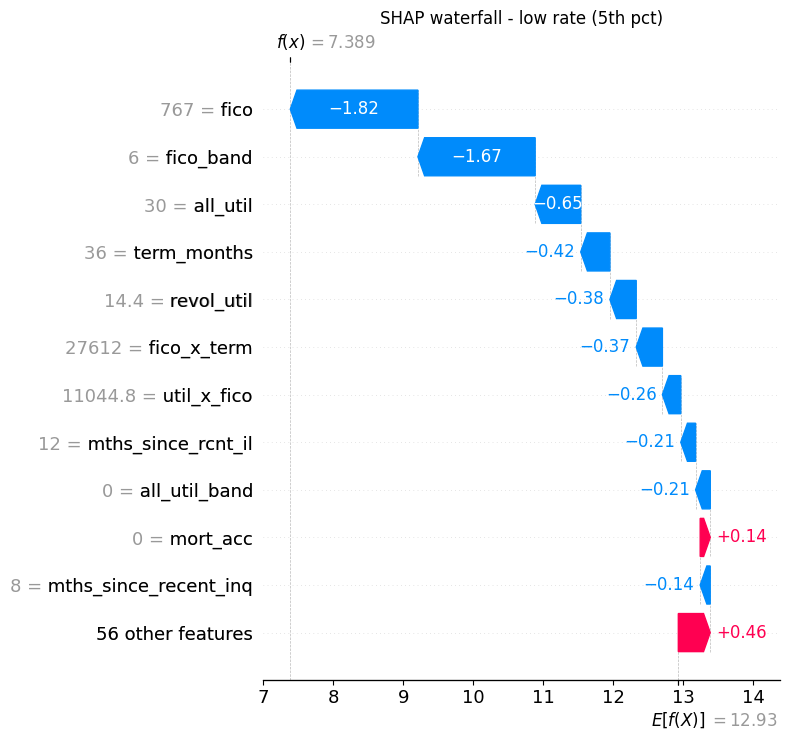

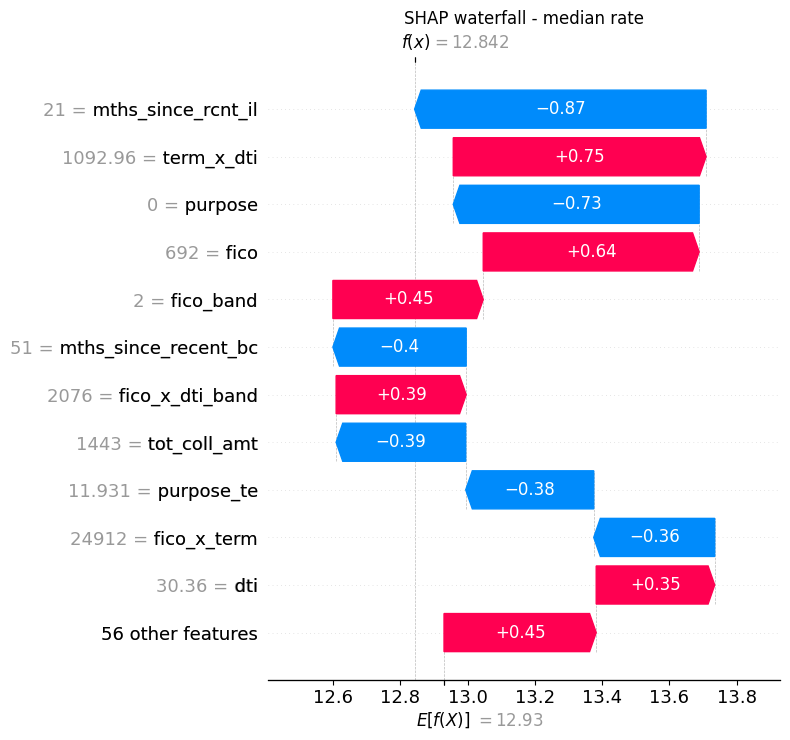

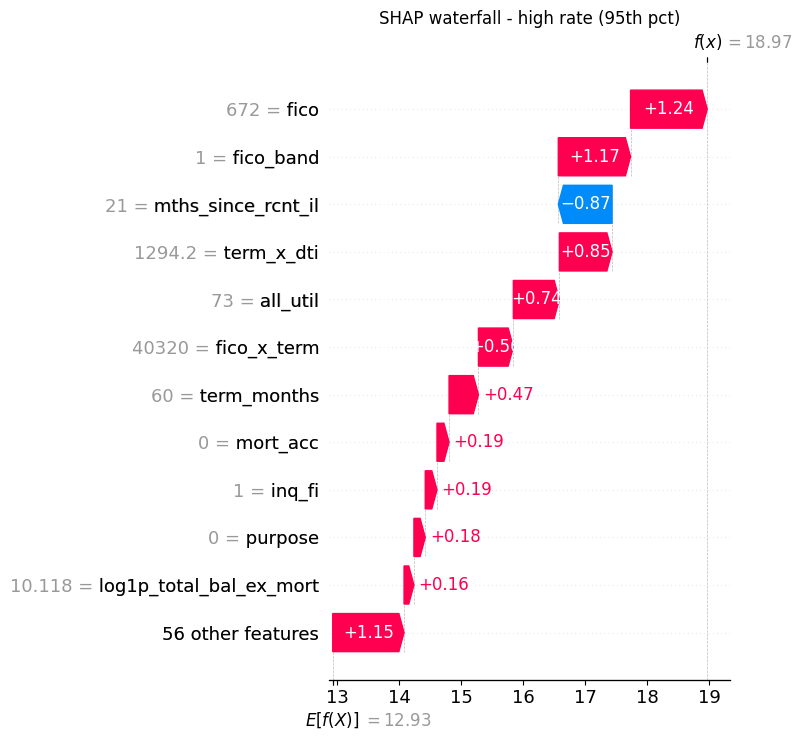

In [21]:
val_preds = val_pred
order = np.argsort(val_preds)
rep_indices = {
    'low rate (5th pct)':   int(order[int(0.05 * len(order))]),
    'median rate':          int(order[len(order) // 2]),
    'high rate (95th pct)': int(order[int(0.95 * len(order))]),
}
print('Representative rows:')
for label, idx in rep_indices.items():
    print('  %-22s idx=%d  predicted=%.2f%%  actual=%.2f%%' % (label, idx, val_preds[idx], y_val[idx]))

for label, idx in rep_indices.items():
    instance_row = Xval_cb_full.iloc[[idx]].reset_index(drop=True)
    pool_inst = Pool(instance_row, cat_features=cat_idx_full)
    shap_with_exp = explain_model.get_feature_importance(pool_inst, type='ShapValues')
    expected = float(shap_with_exp[0, -1])
    shap_values_inst = shap_with_exp[:, :-1]
    instance_dense = cb_to_numeric(instance_row).iloc[0].values
    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(values=shap_values_inst[0], base_values=expected,
                         data=instance_dense, feature_names=list(instance_row.columns)),
        max_display=12, show=False)
    plt.title('SHAP waterfall - ' + label)
    plt.tight_layout()
    plt.savefig(OUT_DIR / ('catboost_shap_waterfall_' + label.split()[0] + '.png'), dpi=120, bbox_inches='tight')
    plt.show()



--- LIME: low rate (5th pct)  (predicted 7.39%, actual 7.02%) ---


,feature,weight
0,fico,-1.086736
1,emp_title=7,-0.965870
2,fico_band,-0.883455
3,all_util,0.432000
4,term_months,0.345652
5,revol_util,0.274227
6,verification_status=1,0.262815
7,zip3=489,-0.243215
8,mo_sin_old_rev_tl_op,-0.188427
9,addr_state=7,0.069090


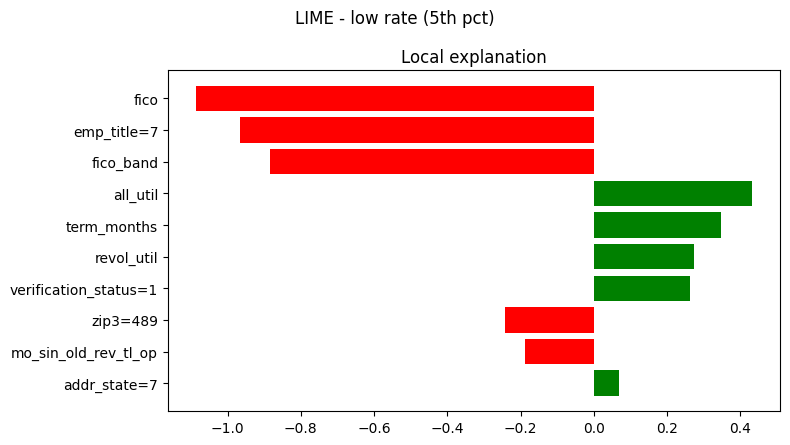


--- LIME: median rate  (predicted 12.84%, actual 7.02%) ---


,feature,weight
0,fico,-1.013116
1,purpose=0,-0.915117
2,fico_band,-0.890883
3,mths_since_recent_bc,-0.419098
4,fico_x_term,0.406880
5,term_months,0.351608
6,mo_sin_old_rev_tl_op,-0.270016
7,purpose_te,0.208432
8,verification_status=0,-0.158869
9,collections_12_mths_ex_med,-0.045615


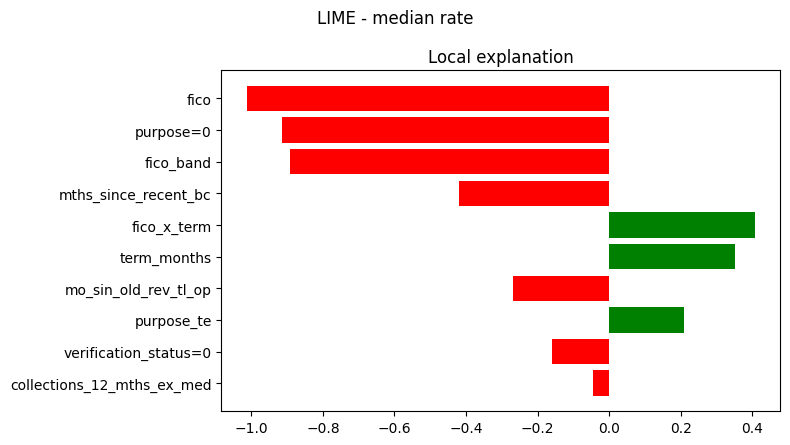


--- LIME: high rate (95th pct)  (predicted 18.97%, actual 20.55%) ---


,feature,weight
0,fico,-1.044233
1,fico_band,-0.908807
2,term_x_dti,0.628350
3,fico_x_term,0.413620
4,all_util,0.407900
5,term_months,0.360822
6,revol_util,0.332668
7,purpose=1,0.292049
8,mths_since_recent_inq,-0.137186
9,verification_status=0,-0.136685


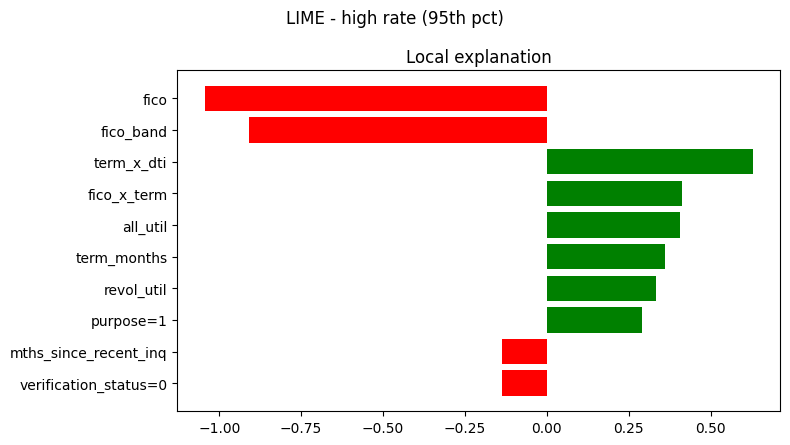

In [22]:
import lime
import lime.lime_tabular

cat_code_maps = {}
cat_train_arrays = {}
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    series_str = Xtr_cb_full[col].astype('string').fillna('Missing')
    codes, uniques = pd.factorize(series_str)
    cat_code_maps[col] = {idx: val for idx, val in enumerate(uniques)}
    cat_train_arrays[col] = codes

Xtr_lime = Xtr_cb_full.copy()
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    Xtr_lime[col] = cat_train_arrays[col]
for j, c in enumerate(Xtr_lime.columns):
    if j not in cat_idx_full:
        Xtr_lime[c] = pd.to_numeric(Xtr_lime[c], errors='coerce').astype('float64')
Xtr_lime_np = Xtr_lime.values.astype('float64')

lime_fill = np.nanmean(Xtr_lime_np, axis=0)
lime_fill = np.where(np.isnan(lime_fill), 0.0, lime_fill)
inds = np.where(np.isnan(Xtr_lime_np))
Xtr_lime_np[inds] = np.take(lime_fill, inds[1])

Xval_lime = Xval_cb_full.copy()
for i in cat_idx_full:
    col = Xval_cb_full.columns[i]
    series_str = Xval_cb_full[col].astype('string').fillna('Missing')
    inv = {v: k for k, v in cat_code_maps[col].items()}
    next_code = max(cat_code_maps[col].keys()) + 1 if cat_code_maps[col] else 0
    Xval_lime[col] = series_str.map(lambda v: inv.get(v, next_code)).astype('int64')
for j, c in enumerate(Xval_lime.columns):
    if j not in cat_idx_full:
        Xval_lime[c] = pd.to_numeric(Xval_lime[c], errors='coerce').astype('float64')
Xval_lime_np = Xval_lime.values.astype('float64')
inds = np.where(np.isnan(Xval_lime_np))
Xval_lime_np[inds] = np.take(lime_fill, inds[1])

lime_categorical_features = [list(Xtr_cb_full.columns).index(c)
                             for c in fp.ALL_CAT_COLS if c in Xtr_cb_full.columns]
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xtr_lime_np,
    feature_names=list(Xtr_cb_full.columns),
    categorical_features=lime_categorical_features,
    mode='regression',
    random_state=fp.RANDOM_STATE,
    discretize_continuous=False,
)


def cb_predict_numeric(X_np):
    df = pd.DataFrame(X_np, columns=Xtr_cb_full.columns)
    for i in cat_idx_full:
        col = Xtr_cb_full.columns[i]
        mapping = cat_code_maps[col]
        codes_int = df[col].round().astype('Int64')
        df[col] = codes_int.apply(lambda v: mapping.get(int(v), 'Missing') if pd.notna(v) else 'Missing').astype('string')
    for j, c in enumerate(df.columns):
        if j not in cat_idx_full:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return explain_model.predict(df)


for label, idx in rep_indices.items():
    instance_np = Xval_lime_np[idx]
    print()
    print('--- LIME: %s  (predicted %.2f%%, actual %.2f%%) ---' % (label, val_preds[idx], y_val[idx]))
    explanation = lime_explainer.explain_instance(instance_np, cb_predict_numeric, num_features=10)
    lime_rows = pd.DataFrame(explanation.as_list(), columns=['feature', 'weight'])
    display(lime_rows)
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(8, 4.5)
    fig.suptitle('LIME - ' + label)
    plt.tight_layout()
    fig.savefig(OUT_DIR / ('catboost_lime_' + label.split()[0] + '.png'), dpi=120, bbox_inches='tight')
    plt.show()


## 16. Cross-split SHAP — train vs validation vs test

Mean |SHAP| per feature on each split. Large train→test drift on a top feature is a
distribution-shift warning.

,feature,mean_abs_train,mean_abs_val,mean_abs_test
0,fico,0.899,0.930,0.937
1,fico_band,0.781,0.822,0.824
2,term_x_dti,0.547,0.541,0.502
3,all_util,0.495,0.502,0.453
4,mths_since_rcnt_il,0.452,0.475,0.455
5,fico_x_term,0.456,0.451,0.429
6,term_months,0.394,0.388,0.378
7,purpose,0.397,0.376,0.378
8,mths_since_recent_bc,0.271,0.279,0.243
9,revol_util,0.244,0.244,0.210


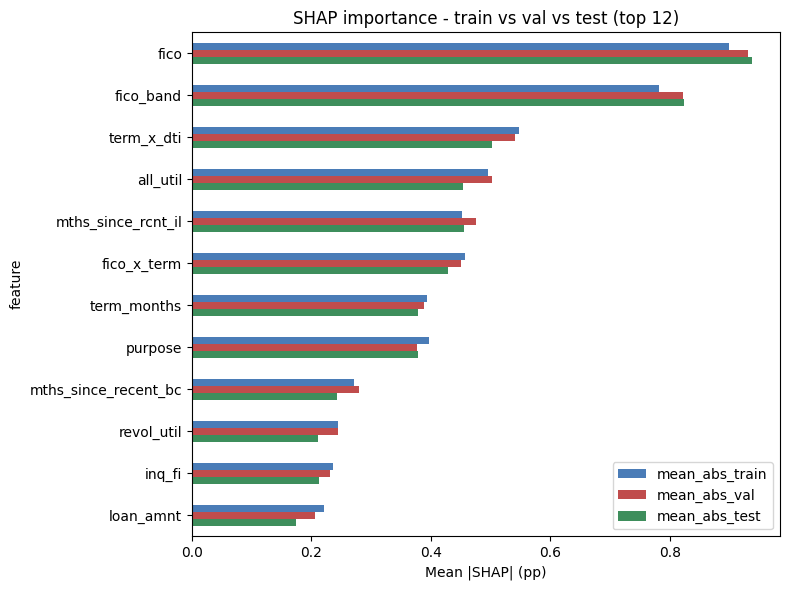

In [23]:
def _native_shap(df_subset):
    pool = Pool(df_subset, cat_features=cat_idx_full)
    arr = explain_model.get_feature_importance(pool, type='ShapValues')
    return arr[:, :-1]


SAMPLE = SHAP_SPLIT_SAMPLE
rng = np.random.default_rng(fp.RANDOM_STATE)
oof_idx_sub  = rng.choice(len(Xtr_cb_full), size=min(SAMPLE, len(Xtr_cb_full)), replace=False)
val_idx_sub  = rng.choice(len(Xval_cb_full), size=min(SAMPLE, len(Xval_cb_full)), replace=False)
test_idx_sub = rng.choice(len(Xte_cb_full), size=min(SAMPLE, len(Xte_cb_full)), replace=False)
shap_train = _native_shap(Xtr_cb_full.iloc[oof_idx_sub].reset_index(drop=True))
shap_val   = _native_shap(Xval_cb_full.iloc[val_idx_sub].reset_index(drop=True))
shap_test  = _native_shap(Xte_cb_full.iloc[test_idx_sub].reset_index(drop=True))

shap_compare = pd.DataFrame({
    'feature':        Xval_cb_full.columns,
    'mean_abs_train': np.abs(shap_train).mean(axis=0),
    'mean_abs_val':   np.abs(shap_val).mean(axis=0),
    'mean_abs_test':  np.abs(shap_test).mean(axis=0),
}).sort_values('mean_abs_val', ascending=False).reset_index(drop=True)
display(shap_compare.head(15).style.format({
    'mean_abs_train': '{:.3f}', 'mean_abs_val': '{:.3f}', 'mean_abs_test': '{:.3f}',
}))
shap_compare.to_csv(OUT_DIR / 'catboost_shap_meanabs_by_split.csv', index=False)

top_feats = shap_compare.head(12)['feature'].tolist()
top_df = shap_compare.set_index('feature').loc[top_feats][['mean_abs_train', 'mean_abs_val', 'mean_abs_test']]
ax = top_df.plot(kind='barh', figsize=(8, 6), color=['#4A7CB7', '#C04C4C', '#3E8E5C'])
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP| (pp)')
ax.set_title('SHAP importance - train vs val vs test (top 12)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_shap_meanabs_by_split.png', dpi=120, bbox_inches='tight')
plt.show()


## 17. Summary

**Part 1** trains a single CatBoost on the 80% train fold (early-stopped on the holdout)
and reports its held-out RMSE / MAE / R2, residual diagnostics, and submission file.

**Part 2** adds the diagnostic suite (live): the CatBoost per-round learning curve, a
data-size learning curve, and an OOF-vs-val residual overlay (OOF built with a live
K-fold CatBoost).

**Part 3** adds the explainability suite (live): permutation importance, CatBoost native
gain, SHAP summary / dependence, PDP / ICE, SHAP waterfall, LIME, and cross-split SHAP —
all on the single CatBoost from Part 1.

**Outputs written to `outputs/final/`** (all `catboost_`-prefixed so they never clobber the
stack's `final_` artifacts): `catboost_test_predictions.csv`, `catboost_residuals.png`,
`catboost_diag_*.png`, `catboost_perm_*`, `catboost_cb_gain_*`, `catboost_shap_*`,
`catboost_pdp_top3.png`, `catboost_ice_top3.png`, `catboost_lime_*.png`.
